# 06 - Adaptive Model Experiment

This notebook tests a simple, inspectable update policy for the Phase 3b Logistic Regression model family. Phase 1 recorded a usable `visit_date` field, so this run uses a real chronological split: earlier visits train the initial model and later visits act as the incoming batch. This is not the random STAND-IN fallback.

## Run the shared Phase 6 implementation

The implementation reuses the corrected preprocessing design from Phases 2-3, balanced Logistic Regression, fixed random seeds, and the tuned Phase 3b cutoff. The initial preprocessing and classifier are fitted only on the earlier batch. Consequently, the fitted output can contain fewer than the Phase 3 model's 52 columns when a category occurs only in later dates; this is preferable to exposing future categories during training.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.adaptive import F1_DROP_TRIGGER, run_phase6

experiment = run_phase6(PROJECT_ROOT / 'data', PROJECT_ROOT / 'results')

Batch mode: real_chronological_split
Real date-based split: earlier dates <= 2024-09-11, later dates > 2024-09-11.
Phase 1-confirmed time column: visit_date
Retrain trigger: later F1 < reference F1 - 0.05
Trigger result: False (later F1 0.515314 >= reference F1 0.519044 - trigger drop 0.05 = 0.469044)

Observed before/after comparison:
                   stage                            model_state            evaluation_scope  train_rows  evaluation_rows  threshold  accuracy  precision   recall       f1  roc_auc  retrain_triggered                                                            trigger_reason
before_adaptive_decision initial_model_trained_on_earlier_batch                 later_batch       17434             7566   0.572596  0.604679   0.354990 0.939716 0.515314 0.767087              False later F1 0.515314 >= reference F1 0.519044 - trigger drop 0.05 = 0.469044
 after_adaptive_decision      initial_model_retained_no_retrain same_later_batch_no_retrain       17434             

## Confirm the chronological batches

The diagnostics below show that the selected field was confirmed in the saved Phase 1 summary and parses successfully. They also show the observed date ranges, row counts, and purchase rates without assuming values in advance.

In [2]:
time_report = pd.DataFrame(experiment['time_reports'])
display(time_report)

batches = experiment['batches']
time_column = experiment['time_column']
earlier_dates = pd.to_datetime(batches['earlier'][time_column], dayfirst=True)
later_dates = pd.to_datetime(batches['later'][time_column], dayfirst=True)
split_summary = pd.DataFrame({
    'batch': ['earlier', 'later'],
    'rows': [len(batches['earlier']), len(batches['later'])],
    'minimum_date': [earlier_dates.min().date(), later_dates.min().date()],
    'maximum_date': [earlier_dates.max().date(), later_dates.max().date()],
    'purchase_rate': [batches['earlier'][experiment['target']].mean(), batches['later'][experiment['target']].mean()],
})
print('Batch mode:', batches['mode'])
print('Description:', batches['description'])
print('Features learned from earlier batch only:', experiment['adaptive_feature_count'])
display(split_summary)

,column,parse_success_percent,unique_timestamps,confirmed_in_phase1_summary
0,visit_date,100.0,365,True


Batch mode: real_chronological_split
Description: Real date-based split: earlier dates <= 2024-09-11, later dates > 2024-09-11.
Features learned from earlier batch only: 49


,batch,rows,minimum_date,maximum_date,purchase_rate
0,earlier,17434,2024-01-01,2024-09-11,0.225077
1,later,7566,2024-09-12,2024-12-30,0.223632


## Evaluate the explicit retraining trigger

The rule is: retrain only if later-batch F1 is more than 0.05 below the Phase 3b tuned-test F1. When the rule does not fire, the after-decision row deliberately repeats the later-batch measurement because the initial model remains unchanged. This prevents the experiment from implying an improvement that did not occur.

In [3]:
print(f"Reference F1: {experiment['reference_f1']:.6f}")
print(f"Allowed drop: {F1_DROP_TRIGGER:.2f}")
print(f"Trigger floor: {experiment['trigger_floor']:.6f}")
print('Retraining triggered:', experiment['triggered'])
print('Decision:', experiment['trigger_reason'])
display(experiment['comparison'].round(6))

Reference F1: 0.519044
Allowed drop: 0.05
Trigger floor: 0.469044
Retraining triggered: False
Decision: later F1 0.515314 >= reference F1 0.519044 - trigger drop 0.05 = 0.469044


,stage,model_state,evaluation_scope,train_rows,evaluation_rows,threshold,accuracy,precision,recall,f1,roc_auc,retrain_triggered,trigger_reason
0,before_adaptive_decision,initial_model_trained_on_earlier_batch,later_batch,17434,7566,0.572596,0.604679,0.35499,0.939716,0.515314,0.767087,False,later F1 0.515314 >= reference F1 0.519044 - t...
1,after_adaptive_decision,initial_model_retained_no_retrain,same_later_batch_no_retrain,17434,7566,0.572596,0.604679,0.35499,0.939716,0.515314,0.767087,False,later F1 0.515314 >= reference F1 0.519044 - t...


## Saved comparison chart

The chart presents the observed metrics exactly as saved in `results/tables/adaptive_before_after.csv`. Equal bars are expected here if the trigger retains the initial model.

Saved table: P:\College\Sem VII Acad\IPRM\Project\results\tables\adaptive_before_after.csv
Saved chart: P:\College\Sem VII Acad\IPRM\Project\results\figures\adaptive_before_after.png


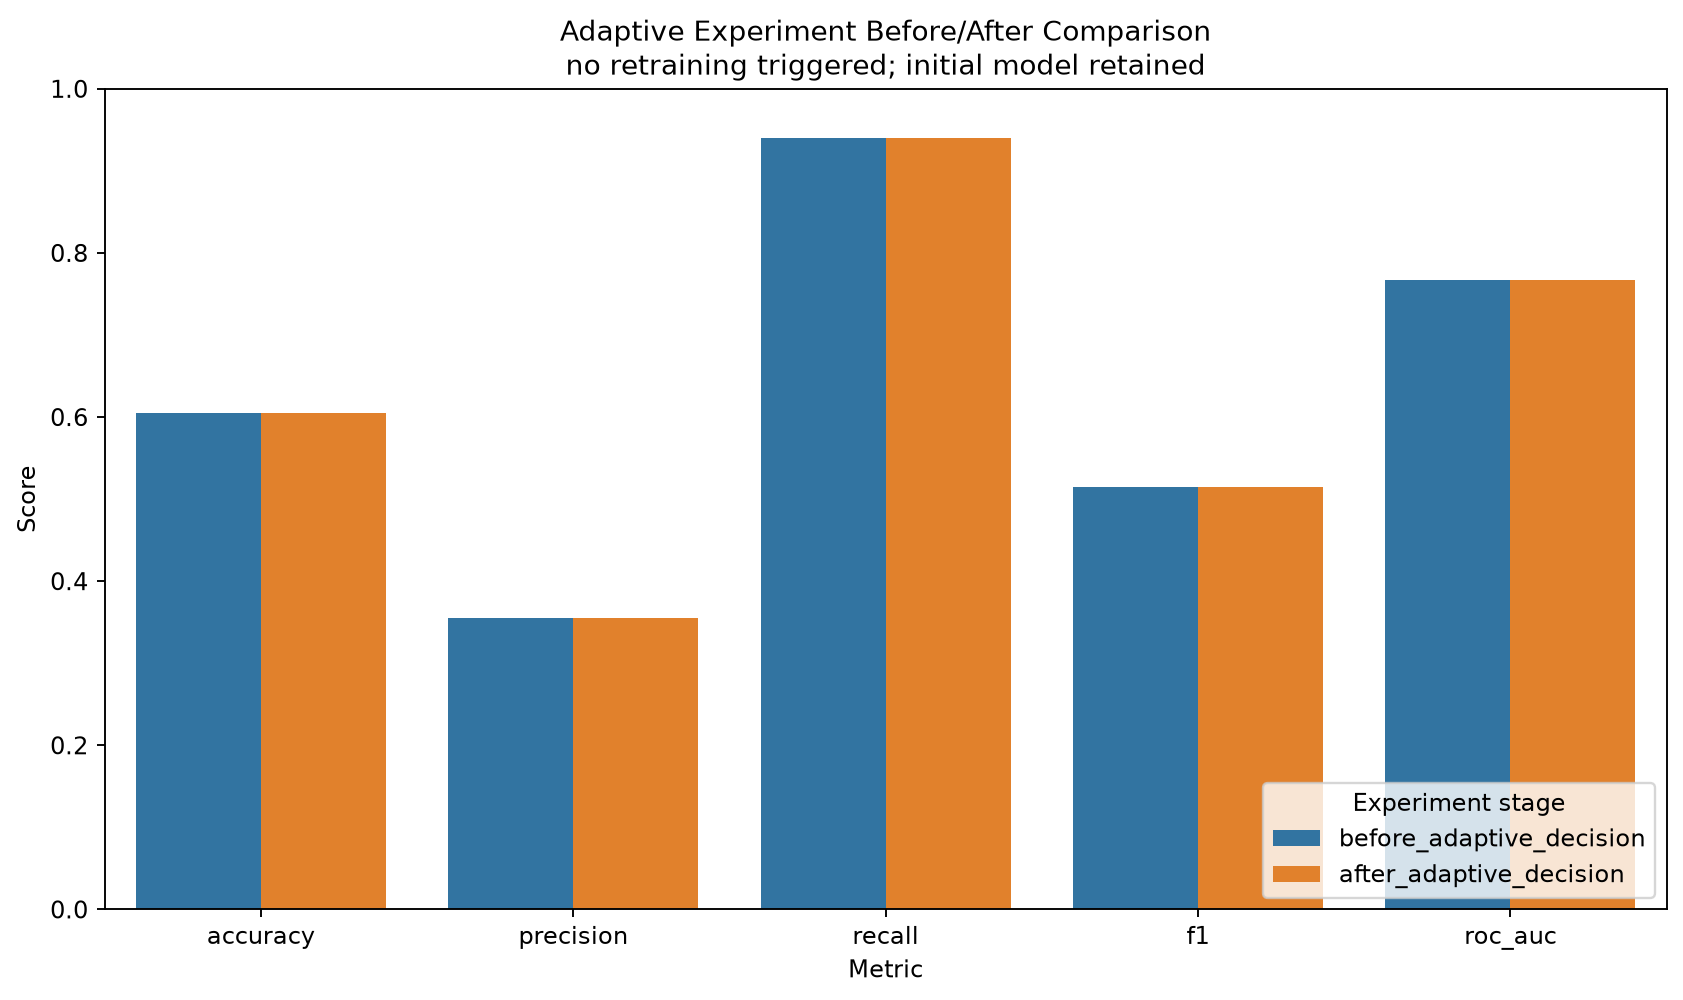

In [4]:
print('Saved table:', experiment['table_path'])
print('Saved chart:', experiment['figure_path'])
display(Image(filename=str(experiment['figure_path'])))

## Phase boundary

Phase 6 ends with this adaptive experiment. The results are reported as observed; no final application integration is performed in this notebook.